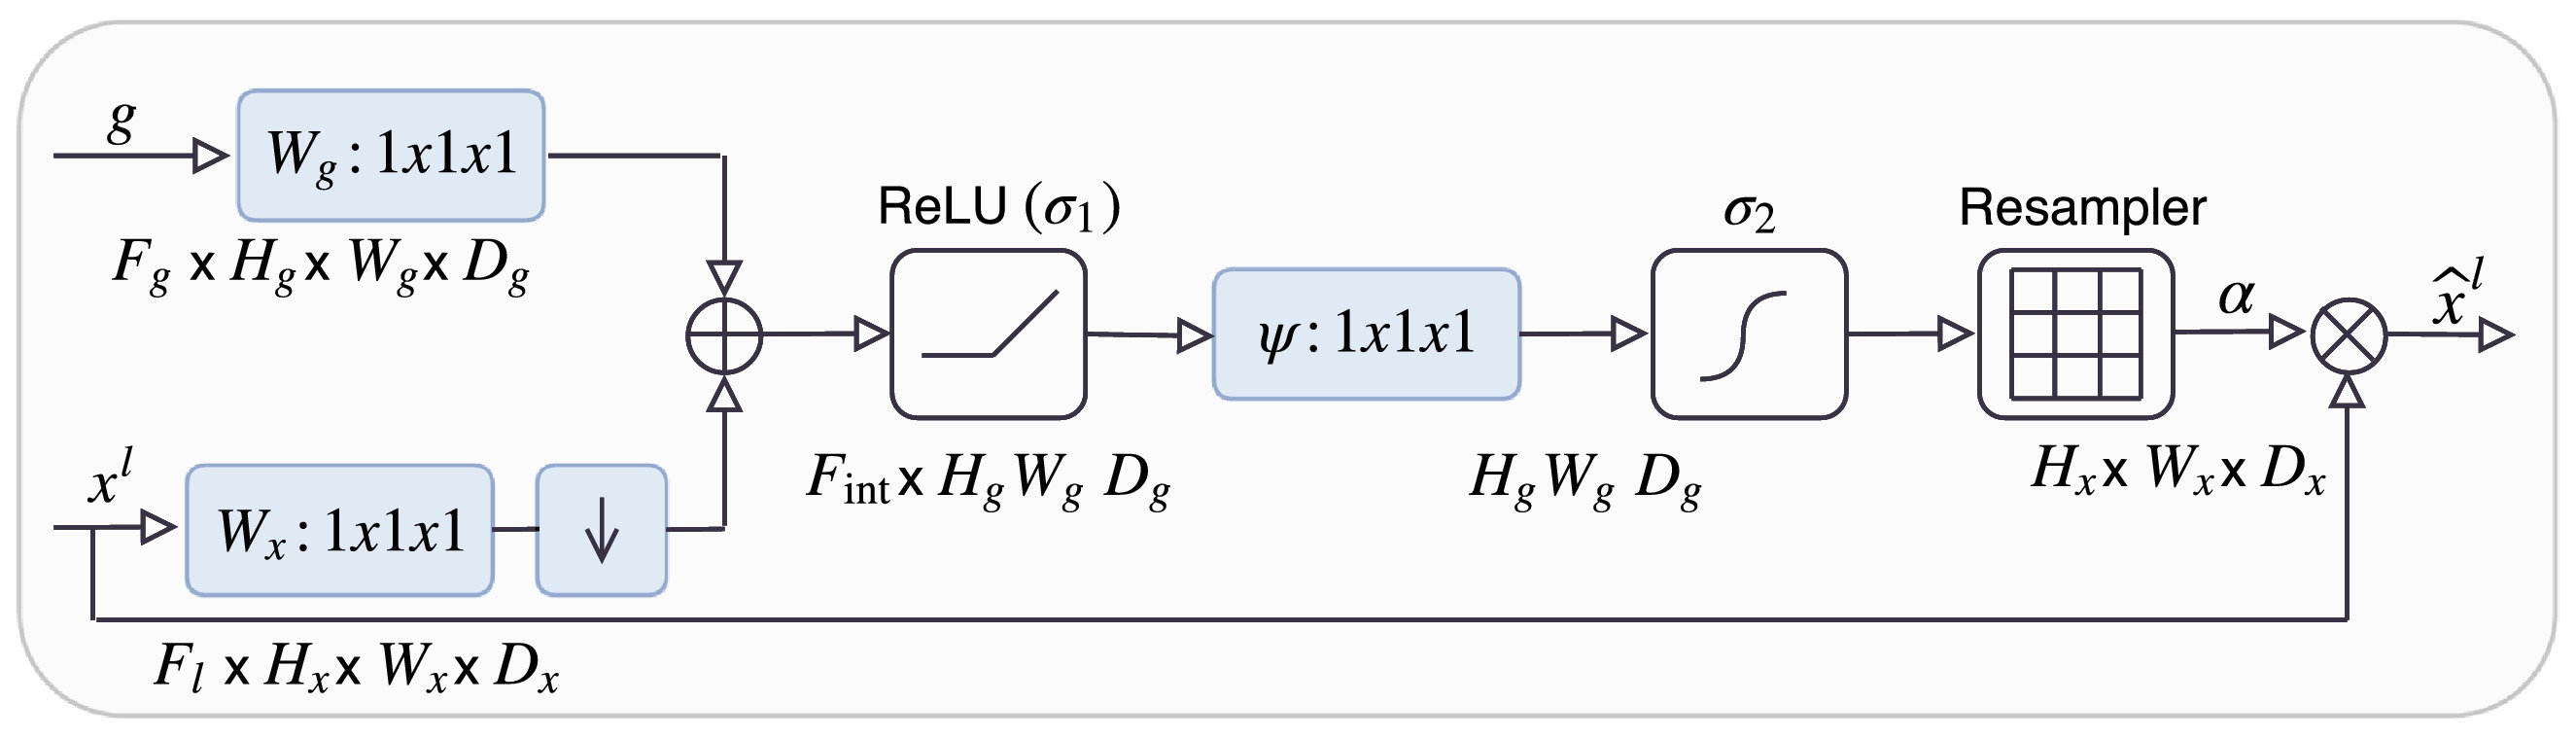

In [1]:
import torch
import torch.nn as nn

In [26]:
class attention_gates(nn.Module):
    def __init__(self,w_g,w_x,f_int):
        super().__init__()
        self.g_x = nn.Conv2d(w_g,f_int,kernel_size=1,stride=1,padding=0)
        self.w_x = nn.Conv2d(w_x,f_int,kernel_size=1,stride=1,padding=0)
        self.conn = nn.Conv2d(f_int,1,kernel_size=1,stride=1,padding=0)
        self.rel = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self,g,x):
        i = self.rel(self.g_x(g)+self.w_x(x))
        attention = self.conn(i)
        return self.sigmoid(attention) * x

In [27]:
ag = attention_gates(8,16,1)
x = torch.randn(1,16,20,20)
g = torch.randn(1,8,20,20)

In [28]:
ag(g,x).shape

torch.Size([1, 16, 20, 20])